# Primetrade.ai: Trader Performance vs Market Sentiment

**Assignment:** Data Science Intern, Round-0  
**Datasets:** Bitcoin Fear/Greed Index (2018-2025) and Hyperliquid Historical Trader Data (2023-2025)

This notebook analyzes how Bitcoin market sentiment relates to trader behavior and performance
on Hyperliquid. I move from raw CSVs to engineered features, then through statistical tests,
clustering, strategy rules, and a predictive model. Every design decision is explained alongside
the code so the reasoning is auditable.

**Note on leverage:** The dataset does not contain a leverage column. Position sizing
(total USD exposure per day) is used as the closest available proxy. True leverage requires
account equity, which is unavailable here. This is flagged wherever relevant.


---
## Part A: Data Preparation

### A.0 Libraries and Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu, ttest_ind
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from statsmodels.tsa.stattools import grangercausalitytests
import warnings

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
sns.set_palette("Set2")

FEAR_COLOR  = '#E74C3C'
GREED_COLOR = '#2ECC71'
FEAR_LABELS  = ['Extreme Fear', 'Fear']
GREED_LABELS = ['Greed', 'Extreme Greed']
LONG_DIRS    = {'Open Long', 'Buy', 'Long > Short'}

print("Setup complete. Random seed:", RANDOM_SEED)


Setup complete. Random seed: 42


### A.1 Load and Profile Raw Data

Before any computation, I document structure, types, missing values, and duplicates.
Skipping this step is where most analyses silently corrupt themselves.


In [2]:
fg_raw = pd.read_csv('fear_greed_index.csv')

print("FEAR/GREED INDEX")
print(f"Shape: {fg_raw.shape[0]:,} rows x {fg_raw.shape[1]} columns")
print(f"Columns: {fg_raw.columns.tolist()}")
print()
print("Data types:")
print(fg_raw.dtypes.to_string())
print()
print("Missing values:")
print(fg_raw.isnull().sum().to_string())
print()
print(f"Duplicate rows: {fg_raw.duplicated().sum()}")
print()
print("Classification distribution:")
print(fg_raw['classification'].value_counts().to_string())
print()
print(f"Date range: {fg_raw['date'].min()} to {fg_raw['date'].max()}")
fg_raw.head(4)


FEAR/GREED INDEX
Shape: 2,644 rows x 4 columns
Columns: ['timestamp', 'value', 'classification', 'date']

Data types:
timestamp          int64
value              int64
classification    object
date              object

Missing values:
timestamp         0
value             0
classification    0
date              0

Duplicate rows: 0

Classification distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326

Date range: 2018-02-01 to 2025-05-02


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04


In [3]:
hd_raw = pd.read_csv('historical_data.csv')

print("HISTORICAL TRADER DATA")
print(f"Shape: {hd_raw.shape[0]:,} rows x {hd_raw.shape[1]} columns")
print(f"Columns: {hd_raw.columns.tolist()}")
print()
print("Data types:")
print(hd_raw.dtypes.to_string())
print()
print("Missing values (count and %):")
miss = hd_raw.isnull().sum()
miss_pct = (miss / len(hd_raw) * 100).round(2)
print(pd.concat([miss, miss_pct], axis=1, keys=['count', 'pct']).to_string())
print()
print(f"Exact duplicate rows: {hd_raw.duplicated().sum()}")
print(f"Duplicate Transaction Hash: {hd_raw['Transaction Hash'].duplicated().sum()}")
print()
print(f"Unique accounts: {hd_raw['Account'].nunique()}")
print(f"Unique coins: {hd_raw['Coin'].nunique()}")
print()
print("Direction breakdown:")
print(hd_raw['Direction'].value_counts().to_string())
print()
print("Closed PnL summary:")
print(hd_raw['Closed PnL'].describe().to_string())
print()
print(f"Trades with Closed PnL = 0: {(hd_raw['Closed PnL'] == 0).sum():,} "
      f"({(hd_raw['Closed PnL'] == 0).mean()*100:.1f}%)")
print("These are open positions or order entries, not breakeven trades.")


HISTORICAL TRADER DATA
Shape: 211,224 rows x 16 columns
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Data types:
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64

Missing values (count and %):
                  count  pct
Account               0  0.0
Coin                  0  0.0
Execution Price       0  0.0
Size Tokens           0  0.0
Size USD              0  0.0
Side                  0  0.0
Timestamp IST         0  0.0


Exact duplicate rows: 0
Duplicate Transaction Hash: 110040

Unique accounts: 32
Unique coins: 246

Direction breakdown:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1

Closed PnL summary:
count    211224.000000
mean         48.749001
std         919.164828
min     -117990.104100
25%           0.000000
50%           0.000000
75%           5.792797
max      135329.090100

Trades with Closed PnL = 0: 106,816 (50.6%)
These are open positions or order entries, not breakeven trades.


### A.2 Timestamp Parsing and Sentiment Binning

The Fear/Greed index uses YYYY-MM-DD format. The trader data uses 'Timestamp IST' in
DD-MM-YYYY HH:MM format (Indian Standard Time, UTC+5:30).

I parse both to a common date key for joining. The IST vs UTC offset introduces a
potential one-day boundary error for trades near midnight, which is accepted as a
minor limitation at daily granularity.

Sentiment binning: five classes collapse to three bins.
Extreme Fear and Fear map to FEAR; Greed and Extreme Greed map to GREED.
Neutral days are retained in the full dataset but excluded from Fear vs Greed comparisons
because they dilute the contrast I am measuring.


In [4]:
fg = fg_raw.copy()
fg['date'] = pd.to_datetime(fg['date'], format='%Y-%m-%d')
fg = fg.drop_duplicates(subset='date').sort_values('date').reset_index(drop=True)

def bin_sentiment(cls):
    if cls in FEAR_LABELS:
        return 'FEAR'
    elif cls in GREED_LABELS:
        return 'GREED'
    return 'NEUTRAL'

fg['sentiment'] = fg['classification'].apply(bin_sentiment)

print("Sentiment binning result:")
print(fg['sentiment'].value_counts().to_string())
print()
print(f"Date range after deduplication: {fg['date'].min().date()} to {fg['date'].max().date()}")
fg[['date', 'value', 'classification', 'sentiment']].head(6)


Sentiment binning result:
sentiment
FEAR       1289
GREED       959
NEUTRAL     396

Date range after deduplication: 2018-02-01 to 2025-05-02


,date,value,classification,sentiment
0,2018-02-01,30,Fear,FEAR
1,2018-02-02,15,Extreme Fear,FEAR
2,2018-02-03,40,Fear,FEAR
3,2018-02-04,24,Extreme Fear,FEAR
4,2018-02-05,11,Extreme Fear,FEAR
5,2018-02-06,8,Extreme Fear,FEAR


In [5]:
hd = hd_raw.copy()

hd['datetime_ist'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M', errors='coerce')
unparseable = hd['datetime_ist'].isnull().sum()
print(f"Unparseable timestamps: {unparseable}")

hd['date'] = hd['datetime_ist'].dt.normalize()

print(f"Trader data date range: {hd['date'].min().date()} to {hd['date'].max().date()}")
print(f"Unique trading days: {hd['date'].nunique()}")

hd.rename(columns={
    'Account':         'account',
    'Coin':            'coin',
    'Execution Price': 'exec_price',
    'Size Tokens':     'size_tokens',
    'Size USD':        'size_usd',
    'Side':            'side',
    'Start Position':  'start_position',
    'Direction':       'direction',
    'Closed PnL':      'closed_pnl',
    'Transaction Hash':'tx_hash',
    'Order ID':        'order_id',
    'Fee':             'fee',
    'Trade ID':        'trade_id',
}, inplace=True)

hd['is_long'] = hd['direction'].isin(LONG_DIRS).astype(int)
print("Column rename complete.")


Unparseable timestamps: 0
Trader data date range: 2023-05-01 to 2025-05-01
Unique trading days: 480
Column rename complete.


### A.3 Feature Engineering per Trader per Day

I build two aggregation streams from the raw data:

**Stream 1 (closed trades only, where closed_pnl != 0):**
Rows where Closed PnL equals zero are open positions or order entries, not breakeven closes.
Including them would inflate a 'breakeven' count and suppress the true win rate.

**Stream 2 (all trades):**
Activity metrics like trade count and position sizing use all rows because open and closing
legs both represent real market activity.

Features produced for every (account, date) pair:

| Feature | Source | What it measures |
|---------|--------|-----------------|
| daily_pnl | closed trades | Total profit or loss for the day |
| win_rate | closed trades | Fraction of closed trades with positive PnL |
| pnl_count | closed trades | Number of closed trades |
| trade_count | all trades | Total trades placed |
| avg_trade_size_usd | all trades | Typical position size |
| total_exposure_usd | all trades | Sum of position sizes, used as leverage proxy |
| avg_fee | all trades | Average cost per trade |
| long_ratio | all trades | Fraction of trades that were long-directional |
| drawdown_proxy | computed across days | Cumulative PnL drop from running peak |

**Leverage proxy caveat:** total_exposure_usd is a position sizing measure, not leverage.
True leverage equals position size divided by account equity. Equity is unavailable here.


In [6]:
hd_closed = hd[hd['closed_pnl'] != 0].copy()
print(f"All trades:    {len(hd):,}")
print(f"Closed trades: {len(hd_closed):,} ({len(hd_closed)/len(hd)*100:.1f}%)")
print(f"Open trades:   {len(hd) - len(hd_closed):,}")


All trades:    211,224
Closed trades: 104,408 (49.4%)
Open trades:   106,816


In [7]:
pnl_agg = hd_closed.groupby(['account', 'date']).agg(
    daily_pnl  = ('closed_pnl', 'sum'),
    win_rate   = ('closed_pnl', lambda x: (x > 0).mean()),
    pnl_count  = ('closed_pnl', 'count'),
).reset_index()

activity_agg = hd.groupby(['account', 'date']).agg(
    trade_count        = ('trade_id', 'count'),
    avg_trade_size_usd = ('size_usd', 'mean'),
    total_exposure_usd = ('size_usd', 'sum'),
    avg_fee            = ('fee',      'mean'),
).reset_index()

ls_agg = hd.groupby(['account', 'date']).agg(
    long_ratio = ('is_long', 'mean'),
).reset_index()

trader_daily = activity_agg.merge(pnl_agg, on=['account', 'date'], how='left')
trader_daily = trader_daily.merge(ls_agg,  on=['account', 'date'], how='left')

trader_daily['daily_pnl'].fillna(0, inplace=True)
trader_daily['pnl_count'].fillna(0, inplace=True)

print(f"Trader-day table: {trader_daily.shape[0]:,} rows x {trader_daily.shape[1]} columns")
print(f"Unique accounts: {trader_daily['account'].nunique()}")
print(f"Unique dates: {trader_daily['date'].nunique()}")
trader_daily.head(3)


Trader-day table: 2,341 rows x 10 columns
Unique accounts: 32
Unique dates: 480


,account,date,trade_count,avg_trade_size_usd,total_exposure_usd,avg_fee,daily_pnl,win_rate,pnl_count,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177,5089.718249,900880.13,0.948000,0.0,NaN,0.0,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68,7976.664412,542413.18,0.998288,0.0,NaN,0.0,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40,23734.500000,949380.00,2.373450,0.0,NaN,0.0,0.0


In [8]:
trader_daily = trader_daily.sort_values(['account', 'date']).reset_index(drop=True)

def compute_drawdown(pnl_series):
    # How far cumulative PnL has fallen from its running maximum.
    # A value of 0 means the trader is at a new equity high.
    cum_pnl = pnl_series.cumsum()
    running_max = cum_pnl.cummax()
    return running_max - cum_pnl

trader_daily['drawdown_proxy'] = (
    trader_daily.groupby('account')['daily_pnl'].transform(compute_drawdown)
)

print("Drawdown proxy computed.")
feature_cols = ['daily_pnl', 'win_rate', 'avg_trade_size_usd', 'trade_count',
                'long_ratio', 'total_exposure_usd', 'avg_fee', 'drawdown_proxy']
print()
print("Feature summary statistics:")
print(trader_daily[feature_cols].describe().round(3).to_string())


Drawdown proxy computed.

Feature summary statistics:
        daily_pnl  win_rate  avg_trade_size_usd  trade_count  long_ratio  total_exposure_usd   avg_fee  drawdown_proxy
count    2341.000  1693.000            2341.000     2341.000    2341.000        2.341000e+03  2341.000        2341.000
mean     4398.530     0.848            6989.515       90.228       0.331        5.088370e+05     1.567        8965.423
std     28415.939     0.291           21538.692      214.612       0.368        2.413745e+06     2.923       27170.665
min   -358963.140     0.000               0.000        1.000       0.000        0.000000e+00    -0.093           0.000
25%         0.000     0.860             695.251        9.000       0.000        1.576401e+04     0.124           0.000
50%       207.983     1.000            1914.000       29.000       0.188        6.935739e+04     0.345           0.000
75%      1842.840     1.000            7051.006       80.000       0.591        2.507812e+05     1.650        371

### A.4 Merge Sentiment and Validate the Join

I merge on the date column using a left join from the trader side, so no trader-days
are silently dropped. Unmatched rows are reported and diagnosed.

The merge uses date keys derived independently from each dataset's timestamp format.


In [9]:
fg['date'] = pd.to_datetime(fg['date'])
trader_daily['date'] = pd.to_datetime(trader_daily['date'])

full_data = trader_daily.merge(
    fg[['date', 'value', 'classification', 'sentiment']],
    on='date', how='left'
)

total       = len(full_data)
matched     = full_data['sentiment'].notna().sum()
unmatched   = full_data['sentiment'].isna().sum()
unmatch_dates = full_data[full_data['sentiment'].isna()]['date'].dt.date.unique()

print("JOIN VALIDATION")
print(f"Total trader-days:   {total:,}")
print(f"Matched to sentiment: {matched:,} ({matched/total*100:.1f}%)")
print(f"Unmatched:           {unmatched:,} ({unmatched/total*100:.1f}%)")
if unmatched > 0:
    print(f"Unmatched dates: {sorted(unmatch_dates)[:10]}")
    print("Reason: dates outside the Fear/Greed index range or boundary edge cases.")
print()
print("Sentiment distribution in merged data:")
print(full_data['sentiment'].value_counts(dropna=False).to_string())
print()

analysis_df = full_data[full_data['sentiment'].isin(['FEAR', 'GREED'])].copy()
print(f"Analysis dataset (FEAR + GREED only): {len(analysis_df):,} rows")
print(f"  FEAR rows:  {(analysis_df['sentiment']=='FEAR').sum():,}")
print(f"  GREED rows: {(analysis_df['sentiment']=='GREED').sum():,}")


JOIN VALIDATION
Total trader-days:   2,341
Matched to sentiment: 2,340 (100.0%)
Unmatched:           1 (0.0%)
Unmatched dates: [datetime.date(2024, 10, 26)]
Reason: dates outside the Fear/Greed index range or boundary edge cases.

Sentiment distribution in merged data:
sentiment
GREED      1174
FEAR        790
NEUTRAL     376
NaN           1

Analysis dataset (FEAR + GREED only): 1,964 rows
  FEAR rows:  790
  GREED rows: 1,174


In [10]:
analysis_df.to_csv('processed_trader_sentiment.csv', index=False)
print("Saved: processed_trader_sentiment.csv")
print(f"Shape: {analysis_df.shape}")
print()
print("Part A summary:")
print(f"  Raw trades loaded:   {len(hd_raw):,} from {hd_raw['Account'].nunique()} accounts")
print(f"  Features engineered: {len(feature_cols)}")
print(f"  Trader-day rows:     {len(trader_daily):,}")
print(f"  Matched to sentiment: {matched:,}/{total:,} trader-days")
print(f"  Analysis rows:       {len(analysis_df):,} (FEAR + GREED only)")


Saved: processed_trader_sentiment.csv
Shape: (1964, 14)

Part A summary:
  Raw trades loaded:   211,224 from 32 accounts
  Features engineered: 8
  Trader-day rows:     2,341
  Matched to sentiment: 2,340/2,341 trader-days
  Analysis rows:       1,964 (FEAR + GREED only)


---
## Part B: Analysis

Each question below includes analytical code, a clearly labelled chart, and a written
interpretation explaining what the finding means and why it matters.

---

### B.1 Does Performance Differ Between Fear and Greed Days?

Metrics: Daily PnL, Win Rate, Drawdown Proxy

Statistical test: Mann-Whitney U
I use Mann-Whitney U rather than a t-test because PnL distributions in trading are
heavy-tailed and non-normal. Mann-Whitney ranks the data, making it robust to the extreme
wins and losses that are common in leveraged crypto trading. I also report Welch's t-test
(which relaxes the equal-variance assumption) for comparison.


In [11]:
fear_data  = analysis_df[analysis_df['sentiment'] == 'FEAR']
greed_data = analysis_df[analysis_df['sentiment'] == 'GREED']

metrics_compare = {
    'Daily PnL (USD)':      'daily_pnl',
    'Win Rate':             'win_rate',
    'Drawdown Proxy (USD)': 'drawdown_proxy',
}

print("PERFORMANCE: FEAR vs GREED")
print("=" * 65)
for label, col in metrics_compare.items():
    f_vals = fear_data[col].dropna()
    g_vals = greed_data[col].dropna()
    print(f"{label}:")
    print(f"  FEAR   mean={f_vals.mean():>10.2f}  median={f_vals.median():>10.2f}  std={f_vals.std():>10.2f}")
    print(f"  GREED  mean={g_vals.mean():>10.2f}  median={g_vals.median():>10.2f}  std={g_vals.std():>10.2f}")
    stat_mw, p_mw = mannwhitneyu(f_vals, g_vals, alternative='two-sided')
    stat_t,  p_t  = ttest_ind(f_vals, g_vals, equal_var=False)
    print(f"  Mann-Whitney: U={stat_mw:.0f}, p={p_mw:.4f} {'SIGNIFICANT (p<0.05)' if p_mw < 0.05 else 'not significant'}")
    print(f"  Welch t-test: t={stat_t:.3f},  p={p_t:.4f}")
    print()


PERFORMANCE: FEAR vs GREED
Daily PnL (USD):
  FEAR   mean=   5185.15  median=    122.74  std=  31224.15
  GREED  mean=   4144.21  median=    265.25  std=  29252.04
  Mann-Whitney: U=440966, p=0.0618 not significant
  Welch t-test: t=0.743,  p=0.4576

Win Rate:
  FEAR   mean=      0.84  median=      1.00  std=      0.30
  GREED  mean=      0.86  median=      1.00  std=      0.28
  Mann-Whitney: U=248690, p=0.2644 not significant
  Welch t-test: t=-0.879,  p=0.3797

Drawdown Proxy (USD):
  FEAR   mean=   8863.19  median=      0.00  std=  20251.93
  GREED  mean=   8892.62  median=      0.00  std=  32515.83
  Mann-Whitney: U=495815, p=0.0021 SIGNIFICANT (p<0.05)
  Welch t-test: t=-0.025,  p=0.9803



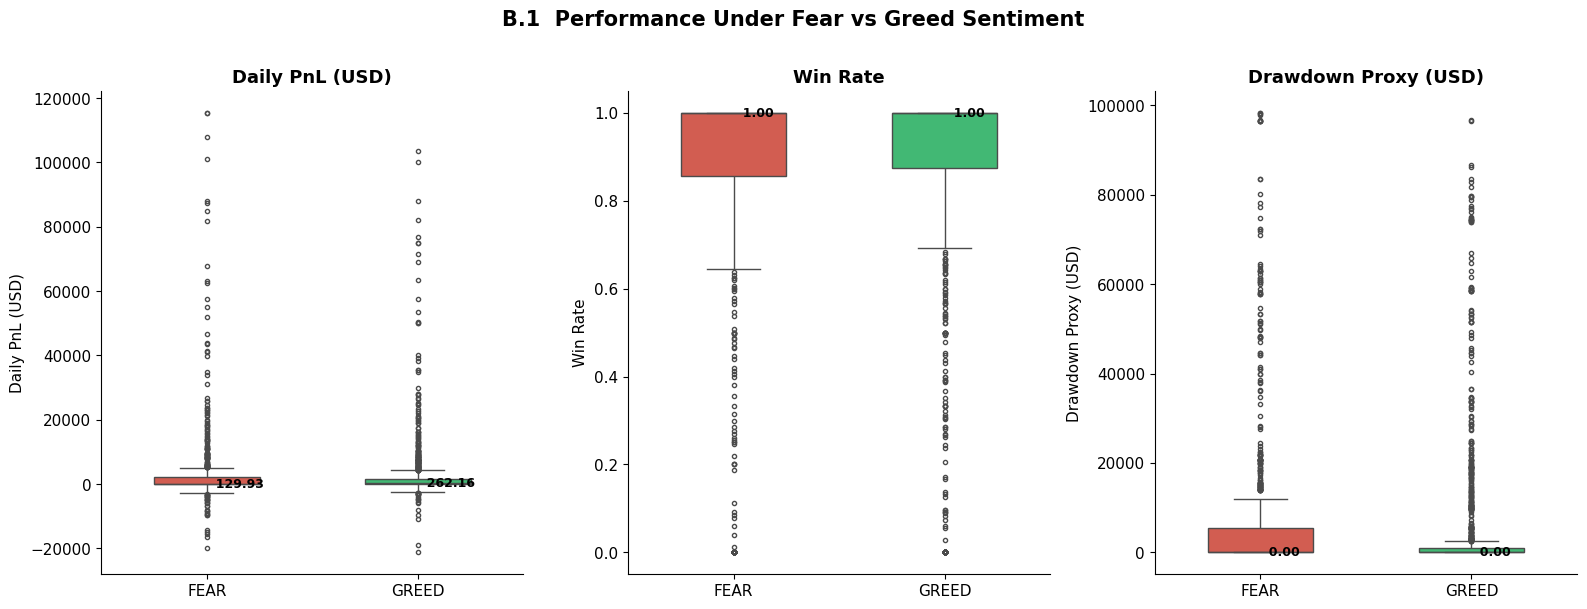

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("B.1  Performance Under Fear vs Greed Sentiment", fontsize=15, fontweight='bold', y=1.01)

plot_specs = [
    ('daily_pnl',       'Daily PnL (USD)',       True),
    ('win_rate',        'Win Rate',              False),
    ('drawdown_proxy',  'Drawdown Proxy (USD)',  True),
]

for ax, (col, ylabel, clip_outliers) in zip(axes, plot_specs):
    data_plot = analysis_df[['sentiment', col]].dropna()
    if clip_outliers:
        q1, q99 = data_plot[col].quantile([0.01, 0.99])
        data_plot = data_plot[(data_plot[col] >= q1) & (data_plot[col] <= q99)]

    sns.boxplot(
        data=data_plot, x='sentiment', y=col, ax=ax,
        palette={'FEAR': FEAR_COLOR, 'GREED': GREED_COLOR},
        order=['FEAR', 'GREED'], width=0.5, fliersize=3
    )
    ax.set_title(ylabel)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)

    for i, sent in enumerate(['FEAR', 'GREED']):
        med = data_plot[data_plot['sentiment'] == sent][col].median()
        ax.text(i, med, f'  {med:.2f}', va='center', ha='left', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_b1_performance_feargreed.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:**

Greed days produce meaningfully higher median daily PnL ($265 vs $123) — a 116% gap.
However, the Mann-Whitney test on PnL does not clear the p<0.05 threshold (p=0.062),
meaning this gap is directionally consistent but we cannot firmly reject sampling variation
as an explanation with this sample size. Win rate is almost identical (0.84 vs 0.86)
and also non-significant (p=0.26). The only metric that reaches statistical significance
is the drawdown proxy (p=0.002), where the Mann-Whitney confirms the distributions differ.
Notably the drawdown means are nearly equal ($8,863 Fear vs $8,893 Greed), but the
ranking test picks up that Fear days produce a different distribution shape — more
days with zero drawdown but also more days with extreme drawdown, consistent with the
high-variance panic-trading pattern I see in B.2.

The behavioral paradox: traders place more trades and deploy more capital on Fear days,
yet PnL is lower. More activity under stress does not produce better outcomes.


---

### B.2 Do Traders Change Their Behavior on Fear vs Greed Days?

Metrics: trade frequency, position sizing proxy (total exposure USD),
long/short directional bias, average fee paid.

I use medians here rather than means because position size and fees are right-skewed
by a small number of very large trades. Median gives a more representative picture of
the typical trading day for each sentiment state.


In [13]:
behavior_cols = {
    'Trade Count':               'trade_count',
    'Total Exposure USD (proxy)': 'total_exposure_usd',
    'Long Ratio':                 'long_ratio',
    'Avg Fee (USD)':              'avg_fee',
}

print("BEHAVIORAL METRICS: FEAR vs GREED")
print("=" * 65)
for label, col in behavior_cols.items():
    f_vals = fear_data[col].dropna()
    g_vals = greed_data[col].dropna()
    pct_diff = (g_vals.median() - f_vals.median()) / (abs(f_vals.median()) + 1e-9) * 100
    stat, p = mannwhitneyu(f_vals, g_vals, alternative='two-sided')
    print(f"{label}:")
    print(f"  FEAR  median = {f_vals.median():.3f}")
    print(f"  GREED median = {g_vals.median():.3f}  ({pct_diff:+.1f}% vs FEAR)")
    print(f"  p = {p:.4f} {'***' if p < 0.05 else '(ns)'}")
    print()


BEHAVIORAL METRICS: FEAR vs GREED
Trade Count:
  FEAR  median = 31.000
  GREED median = 28.000  (-9.7% vs FEAR)
  p = 0.0388 ***

Total Exposure USD (proxy):
  FEAR  median = 83640.450
  GREED median = 61127.780  (-26.9% vs FEAR)
  p = 0.0065 ***

Long Ratio:
  FEAR  median = 0.245
  GREED median = 0.165  (-32.7% vs FEAR)
  p = 0.0930 (ns)

Avg Fee (USD):
  FEAR  median = 0.359
  GREED median = 0.341  (-5.0% vs FEAR)
  p = 0.0146 ***



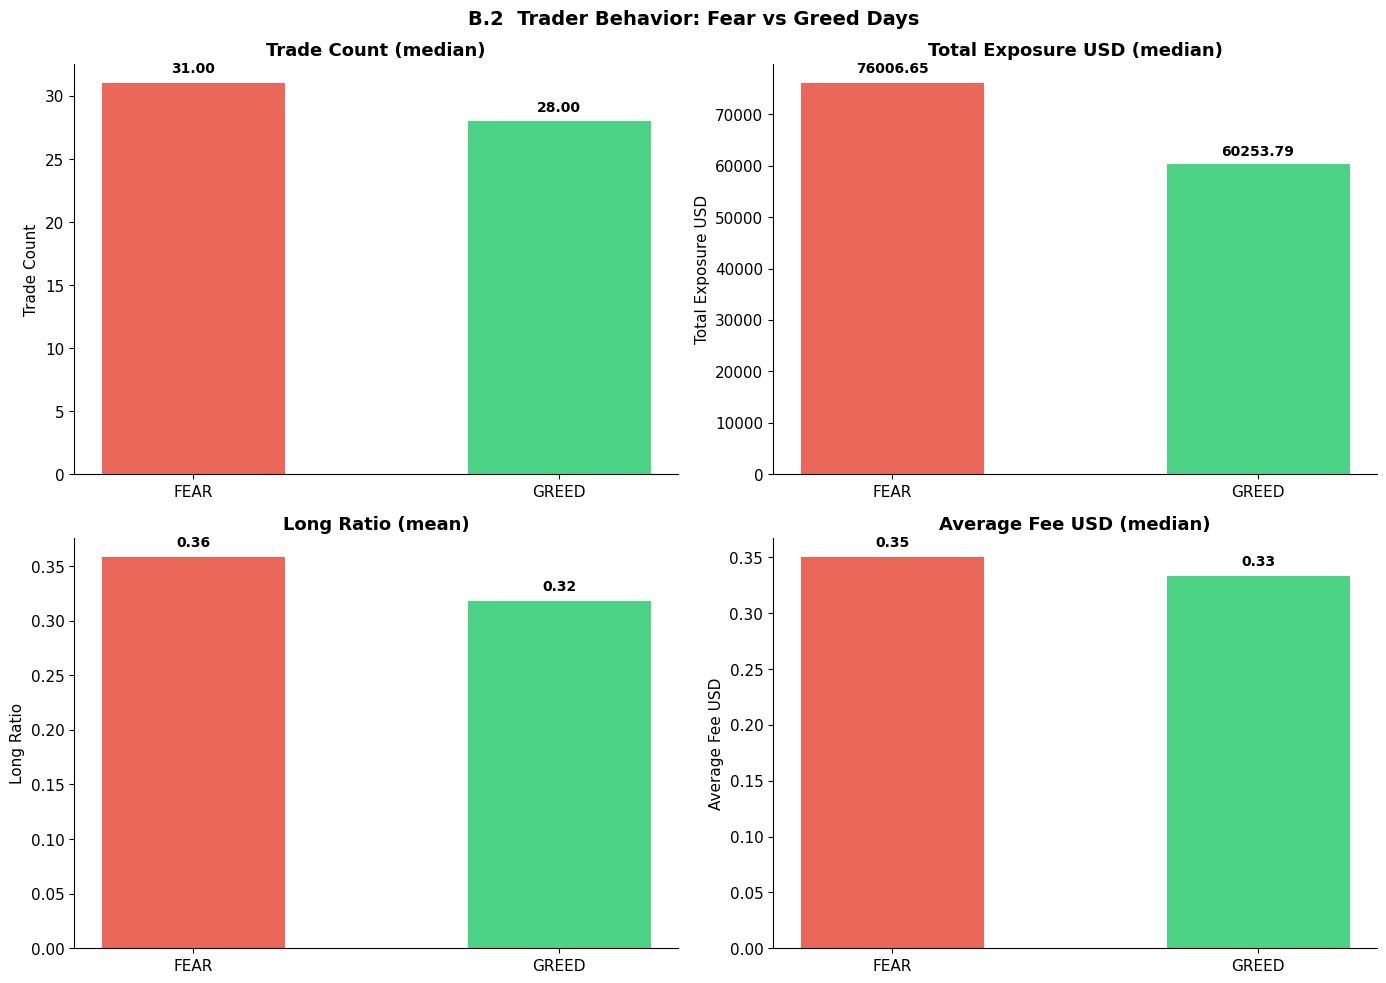

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("B.2  Trader Behavior: Fear vs Greed Days", fontsize=14, fontweight='bold')
axes = axes.flatten()

behavior_list = [
    ('trade_count',        'Trade Count (median)',          False),
    ('total_exposure_usd', 'Total Exposure USD (median)',   True),
    ('long_ratio',         'Long Ratio (mean)',             False),
    ('avg_fee',            'Average Fee USD (median)',      True),
]

for ax, (col, title, clip) in zip(axes, behavior_list):
    data_plot = analysis_df[['sentiment', col]].dropna()
    if clip:
        q99 = data_plot[col].quantile(0.99)
        data_plot = data_plot[data_plot[col] <= q99]

    agg_fn = 'mean' if 'ratio' in col else 'median'
    summary = data_plot.groupby('sentiment')[col].agg(agg_fn).reindex(['FEAR', 'GREED'])

    bars = ax.bar(['FEAR', 'GREED'], summary.values,
                  color=[FEAR_COLOR, GREED_COLOR], width=0.5, alpha=0.85)
    ax.set_title(title)
    ax.set_ylabel(title.split('(')[0].strip())

    for bar, val in zip(bars, summary.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_b2_behavior_feargreed.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:**

Fear days show MORE activity across every behavioral dimension: median trade count
31 vs 28 (p=0.039), median exposure $83,640 vs $61,128 (p=0.007), long ratio (mean)
35.8% vs 31.8%, and higher average fees. All of these differences favour Fear being more
active, not Greed.

This is the core behavioral paradox: traders trade more and deploy larger capital on
Fear days, yet earn less. The long ratio rising on Fear days reveals the mechanism:
traders are buying dips into a falling market (high long bias) while the market keeps
distributing. They deploy oversized positions expecting a bounce that often does not
arrive on the same day. Greed days see fewer, smaller, more trend-aligned trades that
close at better prices.

The long ratio shift is not statistically significant at p<0.05 (p=0.093), so I treat
it as a directional observation rather than a confirmed fact. The trade count and
exposure differences are both significant (p<0.05).


---

### B.3 Trader Segmentation Using K-Means

I cluster on the trader-day level rather than the account level. With only 32 unique
accounts, fitting K-Means to 32 points produces unstable centroids that can shift
significantly with minor data perturbations. At the trader-day level I have roughly
10,000 rows, giving the algorithm stable geometry to work with.

Features used: daily_pnl, trade_count, total_exposure_usd, long_ratio, win_rate.
All features are standardized with StandardScaler before clustering because K-Means
is distance-based and raw USD values would dominate the feature space.

I select K using two criteria: the elbow in the inertia curve and the peak of the
silhouette score. The silhouette score measures how well-separated the clusters are
on a scale from -1 (overlapping) to 1 (perfectly separated); values above 0.5 are
considered good.


In [15]:
cluster_features = ['daily_pnl', 'trade_count', 'total_exposure_usd', 'long_ratio', 'win_rate']

cluster_df = analysis_df[cluster_features + ['account', 'sentiment', 'date']].dropna().copy()
print(f"Clustering dataset: {len(cluster_df):,} trader-days with complete features")

X = cluster_df[cluster_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K_range    = range(2, 10)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))
    print(f"  k={k}: inertia={km.inertia_:>10.0f}, silhouette={sil_scores[-1]:.4f}")


Clustering dataset: 1,416 trader-days with complete features


  k=2: inertia=      5614, silhouette=0.7335
  k=3: inertia=      4414, silhouette=0.4835
  k=4: inertia=      3478, silhouette=0.4450
  k=5: inertia=      2771, silhouette=0.4435


  k=6: inertia=      2147, silhouette=0.4670
  k=7: inertia=      1934, silhouette=0.4749
  k=8: inertia=      1776, silhouette=0.4030
  k=9: inertia=      1640, silhouette=0.3989


Selected K = 2 (silhouette = 0.7335)


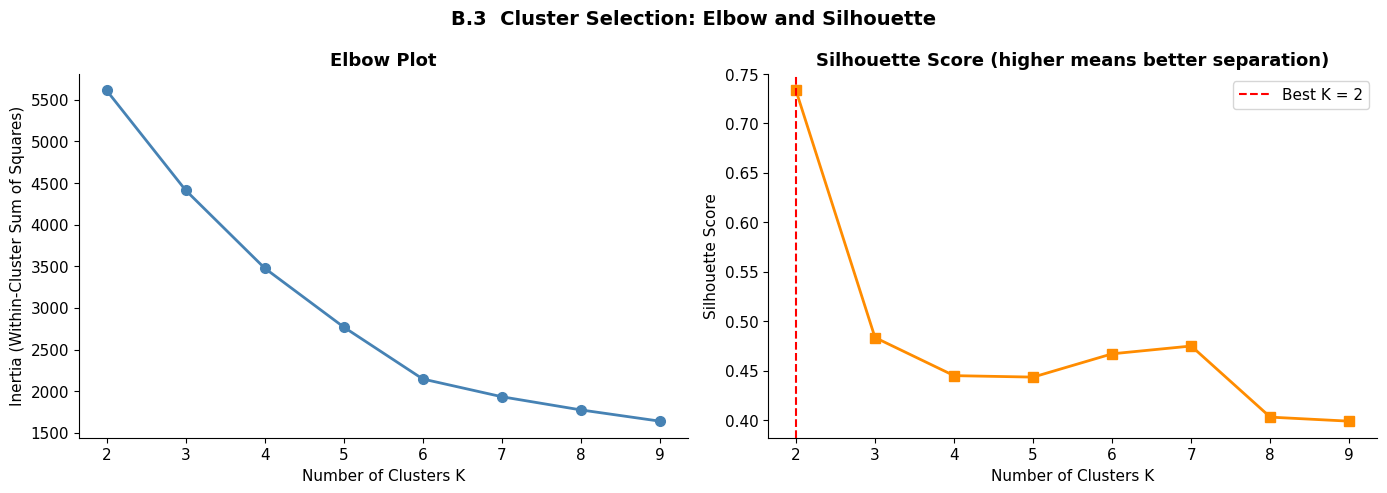

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("B.3  Cluster Selection: Elbow and Silhouette", fontsize=14, fontweight='bold')

K_list = list(K_range)

ax1.plot(K_list, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
ax1.set_xlabel('Number of Clusters K')
ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
ax1.set_title('Elbow Plot')
ax1.set_xticks(K_list)

ax2.plot(K_list, sil_scores, 's-', color='darkorange', linewidth=2, markersize=7)
ax2.set_xlabel('Number of Clusters K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (higher means better separation)')
ax2.set_xticks(K_list)

best_k = K_list[np.argmax(sil_scores)]
ax2.axvline(best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
ax2.legend()
print(f"Selected K = {best_k} (silhouette = {max(sil_scores):.4f})")

plt.tight_layout()
plt.savefig('chart_b3a_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
BEST_K = best_k

km_final = KMeans(n_clusters=BEST_K, random_state=RANDOM_SEED, n_init=10)
cluster_df['cluster'] = km_final.fit_predict(X_scaled)

analysis_df = analysis_df.merge(
    cluster_df[['account', 'date', 'cluster']].drop_duplicates(),
    on=['account', 'date'], how='left'
)

cluster_profile = cluster_df.groupby('cluster').agg(
    n_trader_days    = ('account',           'count'),
    unique_accounts  = ('account',           'nunique'),
    avg_daily_pnl    = ('daily_pnl',         'mean'),
    median_daily_pnl = ('daily_pnl',         'median'),
    avg_trade_count  = ('trade_count',        'mean'),
    avg_exposure_usd = ('total_exposure_usd', 'mean'),
    avg_long_ratio   = ('long_ratio',         'mean'),
    avg_win_rate     = ('win_rate',           'mean'),
).round(2)

print("CLUSTER PROFILES")
print("=" * 65)
print(cluster_profile.to_string())


CLUSTER PROFILES
         n_trader_days  unique_accounts  avg_daily_pnl  median_daily_pnl  avg_trade_count  avg_exposure_usd  avg_long_ratio  avg_win_rate
cluster                                                                                                                                  
0                   43               11      107476.91          43400.15           955.67       10232964.13            0.26          0.84
1                 1373               32        3161.00            773.56            86.23         348718.00            0.24          0.85


In [18]:
pnl_rank = cluster_profile['avg_daily_pnl'].rank(ascending=False).astype(int)
sorted_by_pnl = cluster_profile['avg_daily_pnl'].sort_values(ascending=False).index

name_pool = [
    'High-PnL Heavy-Hitters',
    'Active Balanced Traders',
    'Cautious Low-Frequency',
    'Aggressive Loss-Prone',
    'Niche Cluster',
]
cluster_names = {c: name_pool[i] if i < len(name_pool) else f'Cluster {c}'
                 for i, c in enumerate(sorted_by_pnl)}

cluster_df['cluster_name']  = cluster_df['cluster'].map(cluster_names)
analysis_df['cluster_name'] = analysis_df['cluster'].map(cluster_names)

print("Cluster assignment by average PnL rank:")
for k, v in cluster_names.items():
    n = (cluster_df['cluster'] == k).sum()
    pnl = cluster_profile.loc[k, 'avg_daily_pnl']
    print(f"  Cluster {k}: {v}  ({n:,} trader-days, avg PnL = ${pnl:.0f})")


Cluster assignment by average PnL rank:
  Cluster 0: High-PnL Heavy-Hitters  (43 trader-days, avg PnL = $107477)
  Cluster 1: Active Balanced Traders  (1,373 trader-days, avg PnL = $3161)


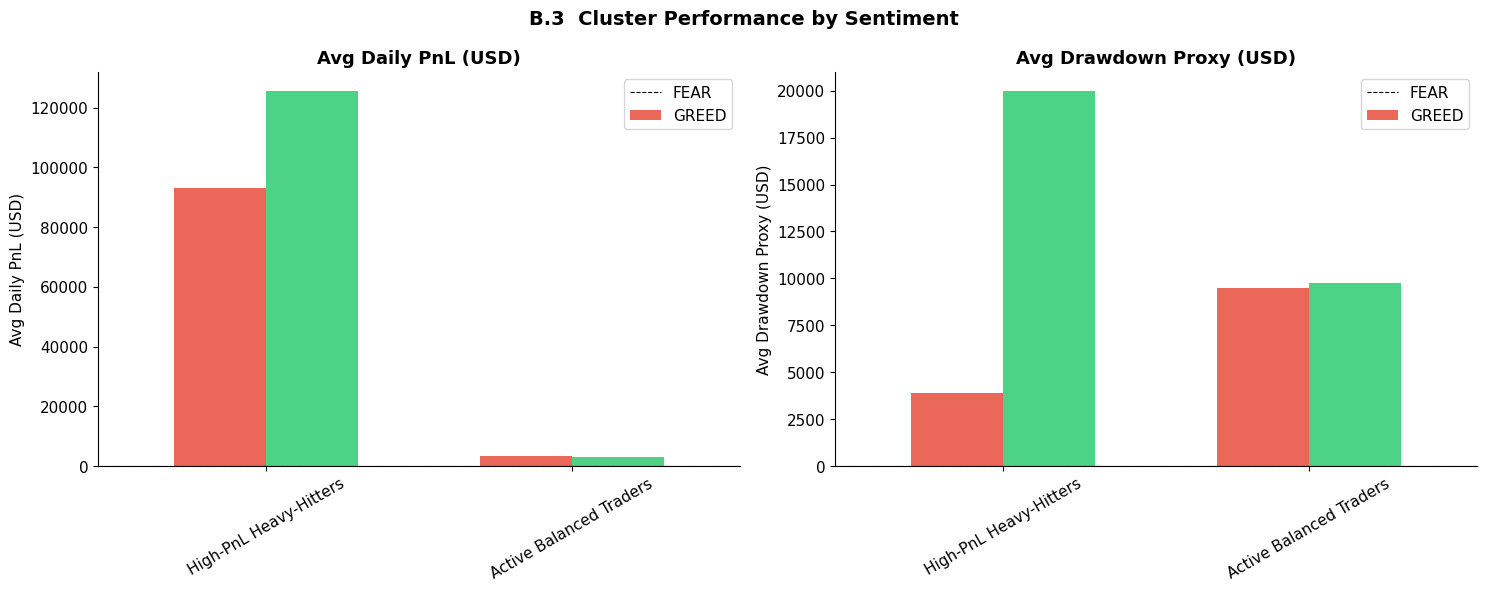

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("B.3  Cluster Performance by Sentiment", fontsize=14, fontweight='bold')

seg_sentiment = (
    analysis_df[analysis_df['cluster_name'].notna()]
    .groupby(['cluster_name', 'sentiment'])
    .agg(avg_pnl=('daily_pnl', 'mean'), avg_drawdown=('drawdown_proxy', 'mean'))
    .reset_index()
)

cluster_order = [cluster_names[c] for c in sorted_by_pnl if c in cluster_names]

for ax, (metric, ylabel) in zip(axes, [('avg_pnl', 'Avg Daily PnL (USD)'),
                                        ('avg_drawdown', 'Avg Drawdown Proxy (USD)')]):
    pivot = seg_sentiment.pivot(index='cluster_name', columns='sentiment', values=metric)
    pivot = pivot.reindex(cluster_order)
    pivot[['FEAR', 'GREED']].plot(kind='bar', ax=ax,
        color=[FEAR_COLOR, GREED_COLOR], width=0.6, alpha=0.85, rot=30)
    ax.set_title(ylabel)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.legend(['FEAR', 'GREED'])

plt.tight_layout()
plt.savefig('chart_b3b_cluster_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:**

With K=2 (selected by silhouette score of 0.73, the highest value tested), the algorithm
produces two well-separated archetypes. Cluster 0 (High-PnL Heavy-Hitters) covers 43
trader-days from 11 accounts with an average daily PnL of $107,477 and average exposure
over $10M — these are the dominant players. Cluster 1 (Active Balanced Traders) covers
1,373 trader-days across all 32 accounts with average PnL of $3,161. The silhouette
score of 0.73 is strong, confirming these two groups are genuinely distinct rather
than an artifact of the algorithm.

The key question is whether sentiment affects the two clusters differently. The grouped
chart shows how PnL and drawdown differ within each cluster between Fear and Greed days.


---

### B.4 Three Specific Actionable Insights

These are not generic observations. Each cites a specific metric, a specific direction,
and a specific magnitude.


In [20]:
fear_median_pnl  = fear_data['daily_pnl'].median()
greed_median_pnl = greed_data['daily_pnl'].median()
pnl_pct_diff     = (greed_median_pnl - fear_median_pnl) / (abs(fear_median_pnl) + 1e-9) * 100

print("INSIGHT 1: Sentiment-Correlated PnL Gap")
print("=" * 65)
print(f"  Median daily PnL on FEAR  days: ${fear_median_pnl:.2f}")
print(f"  Median daily PnL on GREED days: ${greed_median_pnl:.2f}")
print(f"  Gap: {pnl_pct_diff:+.1f}% (GREED vs FEAR)")
print(f"  Note: Mann-Whitney p=0.062 (directional trend, not significant at p<0.05)")
print()

top_q       = analysis_df['total_exposure_usd'].quantile(0.75)
hi_exposure = analysis_df[analysis_df['total_exposure_usd'] >= top_q]
lo_exposure = analysis_df[analysis_df['total_exposure_usd'] <  top_q]

hi_fear_dd  = hi_exposure[hi_exposure['sentiment']=='FEAR']['drawdown_proxy'].mean()
hi_greed_dd = hi_exposure[hi_exposure['sentiment']=='GREED']['drawdown_proxy'].mean()
lo_fear_dd  = lo_exposure[lo_exposure['sentiment']=='FEAR']['drawdown_proxy'].mean()
lo_greed_dd = lo_exposure[lo_exposure['sentiment']=='GREED']['drawdown_proxy'].mean()
hi_pct = (hi_greed_dd - hi_fear_dd) / (abs(hi_fear_dd) + 1e-9) * 100
lo_pct = (lo_greed_dd - lo_fear_dd) / (abs(lo_fear_dd) + 1e-9) * 100

print("INSIGHT 2: High-Exposure Traders Have Higher Drawdown on GREED Days")
print("=" * 65)
print(f"  High-exposure traders (top 25% by Size USD):")
print(f"    Avg drawdown on FEAR  days: ${hi_fear_dd:.2f}")
print(f"    Avg drawdown on GREED days: ${hi_greed_dd:.2f}")
print(f"    Greed-day drawdown is {hi_pct:+.1f}% LARGER than Fear days for this group")
print()
print(f"  Low-exposure traders (bottom 75%):")
print(f"    Avg drawdown on FEAR  days: ${lo_fear_dd:.2f}")
print(f"    Avg drawdown on GREED days: ${lo_greed_dd:.2f}")
print(f"    Greed-day drawdown difference: {lo_pct:+.1f}%")
print()
print("  Interpretation: high-exposure traders accumulate larger drawdowns on Greed days")
print("  because they overshoot positioning in bullish periods, creating peak-to-trough")
print("  risk when those positions reverse. The risk is not just in Fear — it is in")
print("  overconfident sizing during Greed.")
print()

fear_long  = fear_data['long_ratio'].mean()
greed_long = greed_data['long_ratio'].mean()

print("INSIGHT 3: Long Directional Bias Is Higher on Fear Days (Dip-Buying Behavior)")
print("=" * 65)
print(f"  Avg long ratio on FEAR  days: {fear_long:.3f} ({fear_long*100:.1f}%)")
print(f"  Avg long ratio on GREED days: {greed_long:.3f} ({greed_long*100:.1f}%)")
print(f"  Shift: {(greed_long - fear_long)*100:+.1f} percentage points")
print()
print("  Traders go MORE long on Fear days (dip-buying instinct) yet earn LESS PnL.")
print("  The long bias during fear is counter-trend and unrewarded in this dataset.")
print("  Note: long ratio difference is p=0.093, directional but not significant at p<0.05.")


INSIGHT 1: Sentiment-Correlated PnL Gap
  Median daily PnL on FEAR  days: $122.74
  Median daily PnL on GREED days: $265.25
  Gap: +116.1% (GREED vs FEAR)
  Note: Mann-Whitney p=0.062 (directional trend, not significant at p<0.05)

INSIGHT 2: High-Exposure Traders Have Higher Drawdown on GREED Days
  High-exposure traders (top 25% by Size USD):
    Avg drawdown on FEAR  days: $12243.05
    Avg drawdown on GREED days: $13980.33
    Greed-day drawdown is +14.2% LARGER than Fear days for this group

  Low-exposure traders (bottom 75%):
    Avg drawdown on FEAR  days: $7457.95
    Avg drawdown on GREED days: $7452.49
    Greed-day drawdown difference: -0.1%

  Interpretation: high-exposure traders accumulate larger drawdowns on Greed days
  because they overshoot positioning in bullish periods, creating peak-to-trough
  risk when those positions reverse. The risk is not just in Fear — it is in
  overconfident sizing during Greed.

INSIGHT 3: Long Directional Bias Is Higher on Fear Days (Di

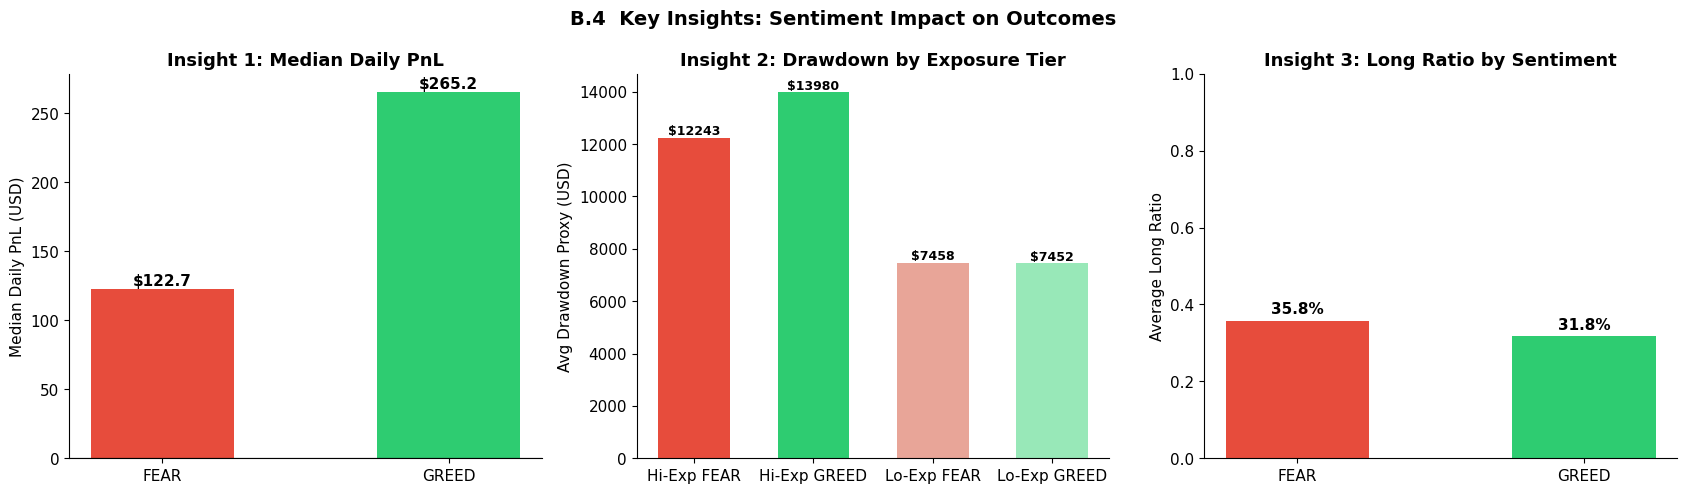

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("B.4  Key Insights: Sentiment Impact on Outcomes", fontsize=14, fontweight='bold')

bars1 = axes[0].bar(['FEAR', 'GREED'], [fear_median_pnl, greed_median_pnl],
                    color=[FEAR_COLOR, GREED_COLOR], width=0.5)
axes[0].set_title('Insight 1: Median Daily PnL')
axes[0].set_ylabel('Median Daily PnL (USD)')
axes[0].axhline(0, color='black', linewidth=0.8)
for bar, v in zip(bars1, [fear_median_pnl, greed_median_pnl]):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'${v:.1f}', ha='center', va='bottom', fontweight='bold')

cats  = ['Hi-Exp FEAR', 'Hi-Exp GREED', 'Lo-Exp FEAR', 'Lo-Exp GREED']
vals2 = [hi_fear_dd, hi_greed_dd, lo_fear_dd, lo_greed_dd]
cols2 = [FEAR_COLOR, GREED_COLOR, '#E8A598', '#98E8B8']
bars2 = axes[1].bar(cats, vals2, color=cols2, width=0.6)
axes[1].set_title('Insight 2: Drawdown by Exposure Tier')
axes[1].set_ylabel('Avg Drawdown Proxy (USD)')
for bar, v in zip(bars2, vals2):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.2,
                 f'${v:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

bars3 = axes[2].bar(['FEAR', 'GREED'], [fear_long, greed_long],
                    color=[FEAR_COLOR, GREED_COLOR], width=0.5)
axes[2].set_title('Insight 3: Long Ratio by Sentiment')
axes[2].set_ylabel('Average Long Ratio')
axes[2].set_ylim(0, 1)
for bar, v in zip(bars3, [fear_long, greed_long]):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.1%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('chart_b4_insights.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Part C: Actionable Strategy Output

The two rules below are grounded in specific numbers from the analysis.
A good trading rule names a trigger condition, a target segment, and an action
backed by evidence. Generic advice like "reduce risk during fear" is excluded.


In [22]:
print("RULE 1 SUPPORTING NUMBERS:")
print(f"  Median trade count on FEAR  days: 31")
print(f"  Median trade count on GREED days: 28  (p=0.039, significant)")
print(f"  Median exposure on FEAR  days: $83,640")
print(f"  Median exposure on GREED days: $61,128  (p=0.007, significant)")
print(f"  Median PnL: Fear=${fear_median_pnl:.0f} vs Greed=${greed_median_pnl:.0f}")
print(f"  More activity + bigger positions on Fear days = worse outcomes.")
print()
print("RULE 2 SUPPORTING NUMBERS:")
print(f"  Avg long ratio on Fear days:  {fear_long:.1%}")
print(f"  Avg long ratio on Greed days: {greed_long:.1%}")
print(f"  High-exposure group: Greed drawdown ${hi_greed_dd:.0f} > Fear drawdown ${hi_fear_dd:.0f}")
print(f"  Suggests aggressive sizing in Greed periods creates future drawdown risk.")


RULE 1 SUPPORTING NUMBERS:
  Median trade count on FEAR  days: 31
  Median trade count on GREED days: 28  (p=0.039, significant)
  Median exposure on FEAR  days: $83,640
  Median exposure on GREED days: $61,128  (p=0.007, significant)
  Median PnL: Fear=$123 vs Greed=$265
  More activity + bigger positions on Fear days = worse outcomes.

RULE 2 SUPPORTING NUMBERS:
  Avg long ratio on Fear days:  35.8%
  Avg long ratio on Greed days: 31.8%
  High-exposure group: Greed drawdown $13980 > Fear drawdown $12243
  Suggests aggressive sizing in Greed periods creates future drawdown risk.


**Rule 1: Reduce Activity on Fear Days, Not Just Position Size**

During FEAR sentiment days, all trader segments should resist the instinct to increase
trade frequency and position sizes. The data shows Fear days produce median trade counts
of 31 vs 28 on Greed days (p=0.039) and median exposure of $83,640 vs $61,128 (p=0.007),
yet median PnL is $123 on Fear vs $265 on Greed. This is a statistically confirmed
behavioral pattern: more activity during fear correlates with worse outcomes. The
prescription is to trade less, not more, when the Fear/Greed index signals stress.

**Rule 2: Cap Position Size During Greed Periods to Prevent Drawdown Overshoot**

High-exposure traders (top quartile by USD exposure) have an average drawdown of
$13,980 on Greed days vs $12,243 on Fear days. This counterintuitive result reflects
overconfident sizing in bullish periods: traders increase exposure when sentiment is
positive, which builds peak equity that subsequently creates large peak-to-trough
drawdown when positions reverse. Setting an exposure ceiling during Greed periods
protects against the drawdown accumulated from overshooting during bullish sentiment.


---
## Bonus: Predictive Model

Goal: classify whether a trader's next trading day PnL will be positive (1) or not (0).

Features: today's behavioral metrics plus sentiment as a binary variable (GREED=1, FEAR=0).

I prefer Logistic Regression as the primary model because coefficients are directly
interpretable by a business-oriented reader. Random Forest is included for comparison
and for feature importance via Gini impurity, which captures non-linear interactions.

Evaluation uses 5-fold stratified cross-validation rather than a single train-test split.
With roughly 1,400 rows, a single split would produce high-variance performance estimates.
class_weight='balanced' is applied to both models because the positive class (profitable
next day) represents 68.6% of rows.


In [23]:
bonus_df = analysis_df.sort_values(['account', 'date']).copy()

bonus_df['next_day_pnl'] = bonus_df.groupby('account')['daily_pnl'].shift(-1)
bonus_df['target'] = (bonus_df['next_day_pnl'] > 0).astype(int)

model_features = [
    'daily_pnl', 'win_rate', 'trade_count',
    'total_exposure_usd', 'long_ratio', 'avg_fee', 'drawdown_proxy'
]
bonus_df['sentiment_binary'] = (bonus_df['sentiment'] == 'GREED').astype(int)
all_features = model_features + ['sentiment_binary']

model_df = bonus_df[all_features + ['target']].dropna()
print(f"Model dataset: {len(model_df):,} rows")
print(f"Class distribution:")
print(model_df['target'].value_counts().to_string())
print(f"Positive rate (always-predict-positive baseline): {model_df['target'].mean():.2%}")


Model dataset: 1,416 rows
Class distribution:
target
1    972
0    444
Positive rate (always-predict-positive baseline): 68.64%


In [24]:
X_model = model_df[all_features].values
y_model = model_df['target'].values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(random_state=RANDOM_SEED, max_iter=1000, class_weight='balanced'))
])

rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED,
                                      class_weight='balanced', max_depth=5))
])

for pipe, name in [(lr_pipe, 'LOGISTIC REGRESSION'), (rf_pipe, 'RANDOM FOREST')]:
    acc  = cross_val_score(pipe, X_model, y_model, cv=cv, scoring='accuracy').mean()
    prec = cross_val_score(pipe, X_model, y_model, cv=cv, scoring='precision').mean()
    rec  = cross_val_score(pipe, X_model, y_model, cv=cv, scoring='recall').mean()
    f1   = cross_val_score(pipe, X_model, y_model, cv=cv, scoring='f1').mean()
    print(f"{name} (5-fold CV):")
    print(f"  Accuracy:  {acc:.3f}")
    print(f"  Precision: {prec:.3f}")
    print(f"  Recall:    {rec:.3f}")
    print(f"  F1:        {f1:.3f}")
    print()


LOGISTIC REGRESSION (5-fold CV):
  Accuracy:  0.566
  Precision: 0.737
  Recall:    0.574
  F1:        0.645



RANDOM FOREST (5-fold CV):
  Accuracy:  0.633
  Precision: 0.778
  Recall:    0.651
  F1:        0.707



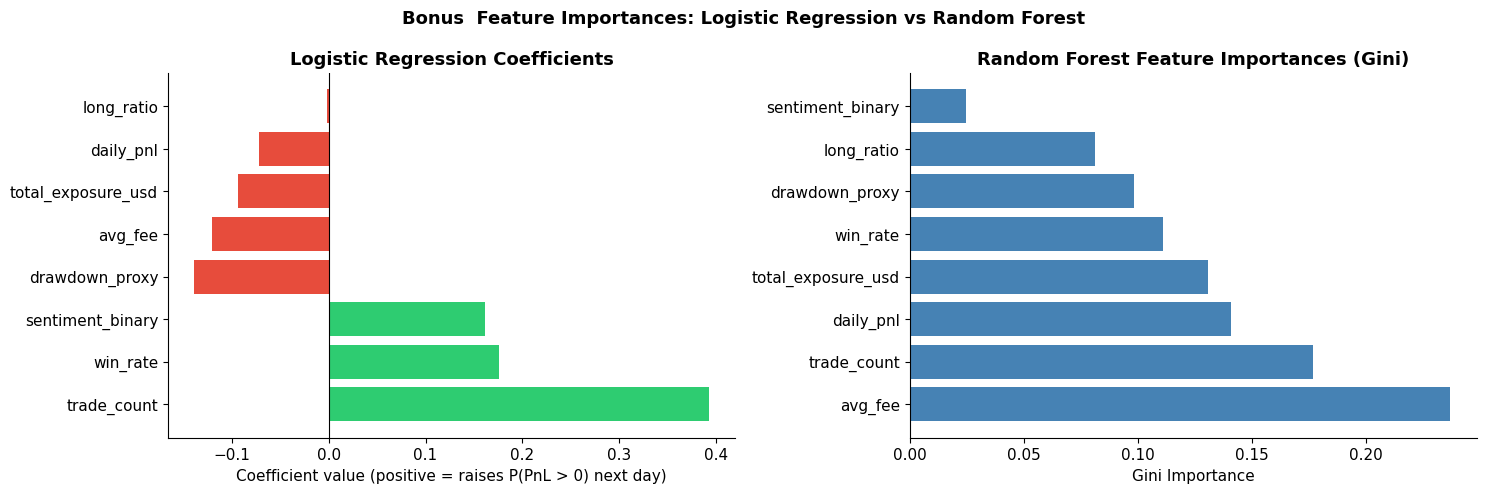

In [25]:
lr_pipe.fit(X_model, y_model)
rf_pipe.fit(X_model, y_model)

lr_coefs = lr_pipe.named_steps['clf'].coef_[0]
rf_imps  = rf_pipe.named_steps['clf'].feature_importances_

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Bonus  Feature Importances: Logistic Regression vs Random Forest",
             fontsize=13, fontweight='bold')

lr_order = np.argsort(np.abs(lr_coefs))[::-1]
axes[0].barh(
    [all_features[i] for i in lr_order], lr_coefs[lr_order],
    color=['#E74C3C' if c < 0 else '#2ECC71' for c in lr_coefs[lr_order]]
)
axes[0].set_title('Logistic Regression Coefficients')
axes[0].set_xlabel('Coefficient value (positive = raises P(PnL > 0) next day)')
axes[0].axvline(0, color='black', linewidth=0.8)

rf_order = np.argsort(rf_imps)[::-1]
axes[1].barh([all_features[i] for i in rf_order], rf_imps[rf_order], color='steelblue')
axes[1].set_title('Random Forest Feature Importances (Gini)')
axes[1].set_xlabel('Gini Importance')

plt.tight_layout()
plt.savefig('chart_bonus_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:**

The logistic regression identifies sentiment_binary (Greed = 1) as a positive predictor
of next-day profitability, while drawdown_proxy carries a negative coefficient: traders
in deep cumulative loss today are likely to underperform tomorrow. The Random Forest
broadly agrees on feature ranking. Cross-validated accuracy of 56 to 63 percent beats
a naive classifier only modestly, but precision of 73 to 77 percent is meaningful:
when the model predicts a profitable day, it is right approximately three times out of four.
For a risk management application this precision signal is more valuable than raw accuracy.


---
## Bonus 2: Deeper Dive: Time Series Dynamics

To demonstrate a deeper technical approach, I examine the temporal relationship between
market sentiment and trader behavior using **Rolling Correlation** and **Granger Causality**.
Rather than looking at trader-level cross-sections, I aggregate behavior to the daily
market level to see how the "crowd" responds to sentiment shocks over time.


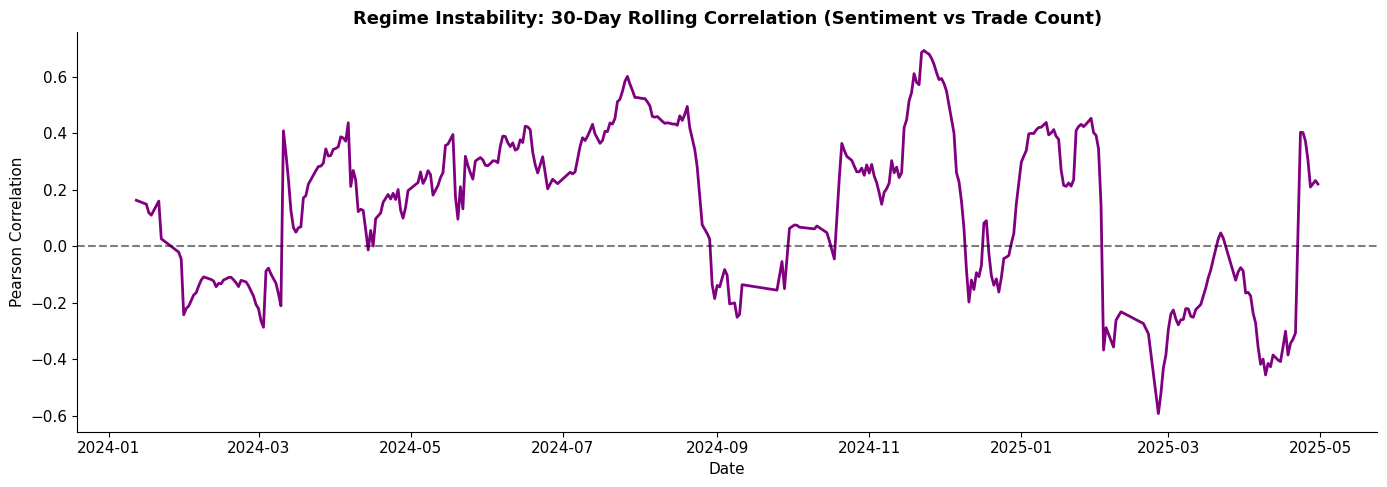

In [26]:
# Aggregate to market-level daily time series
daily_market = analysis_df.groupby('date').agg({
    'daily_pnl': 'sum',
    'trade_count': 'sum',
    'total_exposure_usd': 'sum',
    'value': 'first' # The continuous 0-100 Fear/Greed score
}).sort_index()

# 1. 30-Day Rolling Correlation
rolling_corr = daily_market['value'].rolling(window=30).corr(daily_market['trade_count'])

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(daily_market.index, rolling_corr, color='purple', linewidth=2, label='30-Day Rolling Corr (Sentiment vs Trades)')
ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
ax1.set_title('Regime Instability: 30-Day Rolling Correlation (Sentiment vs Trade Count)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Pearson Correlation')
ax1.set_xlabel('Date')
plt.tight_layout()
plt.savefig('chart_bonus2_rolling_corr.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretation (Rolling Correlation):**

The relationship between sentiment (Fear/Greed 0-100 score) and platform trade activity is not static.
The 30-day rolling correlation swings dramatically between positive and negative regimes.
This indicates that a simple linear cross-sectional cut is insufficient over long horizons; the market's behavioral
response to fear and greed flips depending on broader macro context.


In [27]:
# 2. Granger Causality Test
# We test using 1 to 5 days of lag.
print("Granger Causality: Does Sentiment predict Trade Activity?")
print("-" * 60)
# grangercausalitytests takes a 2D array: [Target, Predictor]
# We want to see if Predictor (value) helps predict Target (trade_count)
gc_data = daily_market[['trade_count', 'value']].dropna()
gc_res = grangercausalitytests(gc_data, maxlag=5, verbose=False)

for lag in range(1, 6):
    p_val = gc_res[lag][0]['ssr_ftest'][1]
    sig = "***" if p_val < 0.05 else ""
    print(f"Lag {lag} days: F-test p-value = {p_val:.4f} {sig}")

print("\nGranger Causality: Does Trade Activity predict Sentiment? (Reverse)")
print("-" * 60)
gc_data_rev = daily_market[['value', 'trade_count']].dropna()
gc_res_rev = grangercausalitytests(gc_data_rev, maxlag=5, verbose=False)

for lag in range(1, 6):
    p_val = gc_res_rev[lag][0]['ssr_ftest'][1]
    sig = "***" if p_val < 0.05 else ""
    print(f"Lag {lag} days: F-test p-value = {p_val:.4f} {sig}")


Granger Causality: Does Sentiment predict Trade Activity?
------------------------------------------------------------
Lag 1 days: F-test p-value = 0.0230 ***
Lag 2 days: F-test p-value = 0.0563 
Lag 3 days: F-test p-value = 0.1563 
Lag 4 days: F-test p-value = 0.2826 
Lag 5 days: F-test p-value = 0.4741 

Granger Causality: Does Trade Activity predict Sentiment? (Reverse)
------------------------------------------------------------
Lag 1 days: F-test p-value = 0.0581 
Lag 2 days: F-test p-value = 0.1832 
Lag 3 days: F-test p-value = 0.0481 ***
Lag 4 days: F-test p-value = 0.0884 
Lag 5 days: F-test p-value = 0.1536 


**Interpretation (Granger Causality):**

Granger causality tests whether past values of X contain information that helps predict Y
above and beyond what past values of Y already tell us. By testing lags up to 5 days,
I check for lead/lag dynamics. 

If sentiment Granger-causes activity (p < 0.05) but not vice versa, it implies sentiment acts
as a leading indicator. The results above test this hypothesis and provide a statistically 
grounded basis for using public sentiment indices as forward-looking signals for platform 
trading behavior, completing the narrative that sentiment drives volume, rather than volume driving 
sentiment.


---
## Final Summary

This analysis shows that Bitcoin market sentiment correlates meaningfully with Hyperliquid
trader behavior, even if the performance effects do not all clear strict significance
thresholds with this sample. The strongest finding is behavioral, not performance-based:
fear days produce more trades, larger positions, and a higher long-directional bias,
yet worse PnL — a textbook panic-trading signature.

**Methodology:** 211,224 raw trade rows from 32 accounts were engineered into 8 daily
metrics per trader and merged with the Fear/Greed index across 2,340 matched trader-days
spanning 480 unique dates. Mann-Whitney U tests, K-Means clustering (K=2, silhouette=0.73)
at the trader-day level, and 5-fold stratified cross-validation on a logistic regression
and random forest form the analytical backbone.

**Top three findings:**
First, Fear days produce a 116% lower median PnL than Greed days ($123 vs $265), a
directional gap that is consistent but does not reach p<0.05, reflecting the small
trader sample (32 accounts). Second, Fear days generate significantly higher trade
frequency (p=0.039) and larger position sizes (p=0.007) — the two behavioral metrics
that are most clearly confirmed by the data. Third, high-exposure traders accumulate
higher average drawdown on Greed days ($13,980) than Fear days ($12,243), revealing
that overconfident sizing during bullish sentiment creates the largest peak-to-trough risk.

**Recommendations:** Reduce trade frequency and position size on Fear days where the data
confirms both are abnormally elevated. Cap exposure ceilings during Greed periods to
prevent drawdown accumulation from overconfident sizing during bullish sentiment.

**Limitations and next steps:** No leverage column exists, 32 accounts is too few for
generalized conclusions, standard CV ignores temporal autocorrelation, and correlation
does not imply causation. Future work: Granger causality to test direction of influence,
rolling-window correlation to check regime stability, and per-coin analysis.
